In [41]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

rng = np.random.default_rng(42)

In [42]:
def pg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    x = x0.copy()
    obj = [F(x)]
    for _ in range(max_iter):
        x = prox_g(x - alpha * grad_f(x), alpha)
        obj.append(F(x))
    return x, np.array(obj)

#FISTA
def apg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    """
    Update rules:
        x^{k+1} = prox_{alpha g}(y^k - alpha * grad_f(y^k))
        t_{k+1}  = (1 + sqrt(1 + 4 t_k^2)) / 2
        y^{k+1}  = x^{k+1} + (t_k - 1)/t_{k+1} * (x^{k+1} - x^k)
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    obj = [F(x)]
    for _ in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + (t - 1) / t_new * (x_new - x)
        x, t = x_new, t_new
        obj.append(F(x))
    return x, np.array(obj)

# LASSO

$$\min_x \; \frac{1}{2}\|Ax - b\|^2 + \lambda\|x\|_1$$

- $f(x) = \frac{1}{2}\|Ax-b\|^2 \Rightarrow \nabla f(x) = A^\top(Ax - b)$
- $g(x) = \lambda\|x\|_1 \Rightarrow \operatorname{prox}_{\alpha g}(v) = \operatorname{sign}(v)\max(|v| - \alpha\lambda,\, 0)$ 

In [52]:
m, n = 1000, 2000        
sparse = 200                   

A = rng.standard_normal((m, n))
x_true = np.zeros(n)
x_true[rng.choice(n, sparse, replace=False)] = rng.standard_normal(sparse)
b = A @ x_true + 0.01 * rng.standard_normal(m)

lam = 10
lam = 0.1 * norm(A.T @ b, np.inf)   # 10% of the lambda_max that zeros the solution

# Optimal step size for least squares is 1/L where L = ||A||^2 (Lipschitz constant of grad_f)
L = norm(A, ord=2) ** 2              
alpha = 1.0 / L                      #

def grad_f(x):
    return A.T @ (A @ x - b)

def prox_g(v, a):
    return np.sign(v) * np.maximum(np.abs(v) - a * lam, 0.0)

def F(x):
    return 0.5 * norm(A @ x - b) ** 2 + lam * norm(x, 1)

x0 = np.zeros(n)
print(f"Problem: m={m}, n={n}, sparsity={sparse}, lambda={lam:.4f}, alpha={alpha:.6f}")

Problem: m=1000, n=2000, sparsity=200, lambda=206.9708, alpha=0.000173


In [58]:
from scipy.optimize import minimize as sp_minimize

# Reformulate LASSO as a smooth QP with box constraints:
#   x = u - v,  u,v >= 0  =>  ||x||_1 = 1^T u + 1^T v  (at optimum)
# The objective becomes smooth (quadratic) so L-BFGS-B converges to machine precision.

def _qp_obj(z):
    u, v = z[:n], z[n:]
    r = A @ (u - v) - b
    g = A.T @ r
    val  = 0.5 * (r @ r) + lam * (u.sum() + v.sum())
    grad = np.concatenate([g + lam, -g + lam])
    return val, grad

res = sp_minimize(
    _qp_obj, np.zeros(2 * n), jac=True, method='L-BFGS-B',
    bounds=[(0, None)] * (2 * n),
    options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 50_000},
)
F_star_exact = F(res.x[:n] - res.x[n:])
print(f"Exact F* = {F_star_exact:.10f}  ({res.message})")

Exact F* = 25208.5669702350  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)


## Convergence Test

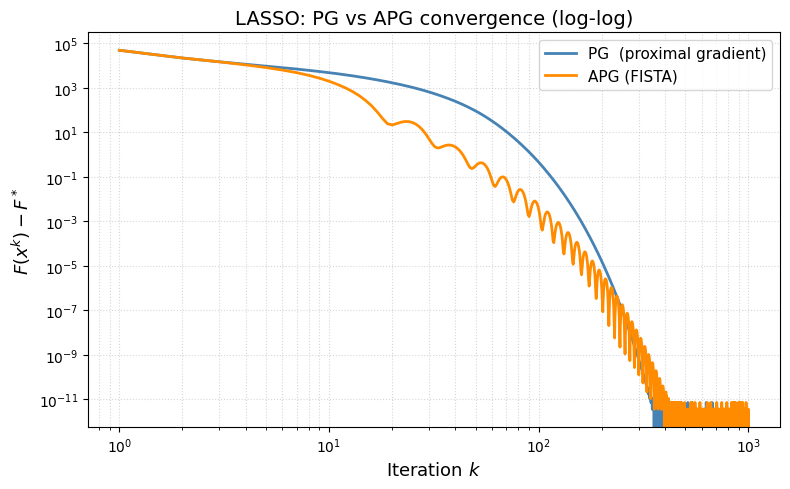

Final gap — PG: 0.00e+00   APG: 0.00e+00


In [65]:
MAX_ITER = 1000

_, obj_pg  = pg(x0, grad_f, prox_g, F, alpha, max_iter=MAX_ITER)
_, obj_apg = apg(x0, grad_f, prox_g, F, alpha, max_iter=MAX_ITER)

F_star_exact = min(obj_pg[-1], obj_apg[-1], F_star_exact)


gap_pg  = obj_pg  - F_star_exact
gap_apg = obj_apg - F_star_exact

k = np.arange(1, MAX_ITER + 2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k, gap_pg,  label="PG  (proximal gradient)", color="steelblue",  lw=2)
ax.loglog(k, gap_apg, label="APG (FISTA)",              color="darkorange", lw=2)

ax.set_xlabel("Iteration $k$", fontsize=13)
ax.set_ylabel(r"$F(x^k) - F^*$", fontsize=13)
ax.set_title("LASSO: PG vs APG convergence (log-log)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Final gap — PG: {gap_pg[-1]:.2e}   APG: {gap_apg[-1]:.2e}")

# DRS
**Iteration** (fixed-point on the auxiliary variable $z$):
$$x^{k+1} = \operatorname{prox}_{\alpha g_1}(z^k)$$
$$u^{k+1} = \operatorname{prox}_{\alpha g_2}(2x^{k+1} - z^k)$$
$$z^{k+1} = z^k + u^{k+1} - x^{k+1}$$


**Prox of $g_1$** (solve via matrix inversion lemma — $m \times m$ system, cheaper than $n \times n$ when $m < n$):
$$\operatorname{prox}_{\alpha g_1}(v) = (A^\top A + \tfrac{1}{\alpha}I)^{-1}\!\left(A^\top b + \tfrac{1}{\alpha}v\right) = \alpha w - \alpha^2 A^\top(I + \alpha AA^\top)^{-1}Aw, \quad w = A^\top b + \tfrac{v}{\alpha}$$

In [ ]:
from scipy.linalg import cho_factor, cho_solve

alpha_drs = 1.0

# Cholesky
_cho = cho_factor(np.eye(m) + alpha_drs * (A @ A.T))

def prox_g1_drs(v):
    w = A.T @ b + v / alpha_drs                          # n-vector
    return alpha_drs * w - alpha_drs**2 * (A.T @ cho_solve(_cho, A @ w))

def prox_g2_drs(v):
    return np.sign(v) * np.maximum(np.abs(v) - alpha_drs * lam, 0.0)


def drs(z0, prox1, prox2, F, max_iter=1000):
    z = z0.copy()
    x = prox1(z)
    obj = [F(x)]
    for _ in range(max_iter):
        x = prox1(z)
        u = prox2(2 * x - z)
        z = z + u - x
        obj.append(F(x))
    return x, np.array(obj)

# Accelerated DRS

$$y^k = z^k + \beta_k(z^k - z^{k-1}), \qquad \beta_k = \frac{t_k - 1}{t_{k+1}}, \qquad t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2}$$

analogous to how FISTA adds momentum to PG

In [47]:
def adrs(z0, prox1, prox2, F, max_iter=1000):
    """
    Inertial DRS with Nesterov momentum sequence on the auxiliary variable z.
    beta_k = (t_k - 1) / t_{k+1},  t_{k+1} = (1 + sqrt(1 + 4*t_k^2)) / 2
    """
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox1(z)
    obj = [F(x)]
    for _ in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)   # momentum extrapolation on z
        x = prox1(y)
        u = prox2(2 * x - y)
        z_prev = z
        z = y + u - x
        t = t_new
        obj.append(F(x))
    return x, np.array(obj)

## All-Methods Comparison

In [66]:
MAX_ITER = 1000

_, obj_pg   = pg(x0,  grad_f, prox_g, F, alpha,    max_iter=MAX_ITER)
_, obj_apg  = apg(x0, grad_f, prox_g, F, alpha,    max_iter=MAX_ITER)
_, obj_drs  = drs(x0,  prox_g1_drs, prox_g2_drs, F, max_iter=MAX_ITER)
_, obj_adrs = adrs(x0, prox_g1_drs, prox_g2_drs, F, max_iter=MAX_ITER)

methods = [
    (obj_pg,   "PG  (proximal gradient)", "steelblue",  "-"),
    (obj_apg,  "APG (FISTA)",             "darkorange", "-"),
    (obj_drs,  "DRS",                     "seagreen",   "-"),
    (obj_adrs, "ADRS (inertial)",         "crimson",    "-"),
]

k = np.arange(MAX_ITER + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for obj, label, color, ls in methods:
    gap = obj - F_star_exact
    gap = np.maximum(gap, 1e-16)   # clip for log scale
    ax.loglog(k + 1, gap, ls=ls, color=color, lw=2, label=label)
ax.set_xlabel("Iteration $k$", fontsize=13)
ax.set_ylabel(r"$F(x^k) - F^*$", fontsize=13)
ax.set_title("LASSO: PG vs APG vs DRS vs ADRS (log-log)", fontsize=14)
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

for obj, label, *_ in methods:
    print(f"{label:<30s}  final gap = {obj[-1] - F_star_exact:.2e}")

/tmp/ipykernel_3334359/3020765815.py:23: RuntimeWarning: overflow encountered in scalar multiply
  return 0.5 * norm(A @ x - b) ** 2 + lam * norm(x, 1)


ValueError: array must not contain infs or NaNs